In [ ]:
# Import the Essential Libraries
import re 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer,ENGLISH_STOP_WORDS


# Load the Dataset 
df =  pd.read_csv('blogs.csv')

In [3]:
print('columns in the dataset: ', df.columns.tolist())

columns in the dataset:  ['Data', 'Labels']


In [4]:
print('number of rows in the dataset: ', df.shape[0])
print('number of columns in the dataset: ', df.shape[1])

number of rows in the dataset:  2000
number of columns in the dataset:  2


In [5]:
print('null values in the dataset: ', df.isnull().sum())

null values in the dataset:  Data      0
Labels    0
dtype: int64


In [6]:
print('how many blogs per category are there?:',df['Labels'].value_counts())

how many blogs per category are there?: Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64


In [7]:
# clean the text 
# cleaning function to preprocess the text data
stop_words_set = set(ENGLISH_STOP_WORDS)  # Convert to set for faster lookup

def clean_text(text):
    text = text.lower() # converts to lowercase
    text = re.sub(r'[^a-z\s]','',text) # remove punctuation and numbers
    words = text.split() # split the text into words
    words = [word for word in words if word not in stop_words_set]
    return ' '.join(words) 

# apply the cleaning function to the text column
df['Cleaned_Blogs'] = df['Data'].apply(clean_text)

# See the difference``
print("\n--- Before Cleaning ---")
print(df['Data'].iloc[0][:200])

print("\n--- After Cleaning ---")
print(df['Cleaned_Blogs'].iloc[0][:200])


--- Before Cleaning ---
Path: cantaloupe.srv.cs.cmu.edu!magnesium.club.cc.cmu.edu!news.sei.cmu.edu!cis.ohio-state.edu!zaphod.mps.ohio-state.edu!howland.reston.ans.net!agate!doc.ic.ac.uk!uknet!mcsun!Germany.EU.net!thoth.mchp.

--- After Cleaning ---
path cantaloupesrvcscmuedumagnesiumclubcccmuedunewsseicmueducisohiostateeduzaphodmpsohiostateeduhowlandrestonansnetagatedocicacukuknetmcsungermanyeunetthothmchpsnidehorusapmchpsnidedsfrank frankdsuucp


In [8]:
# Convert text to numbers using TF-IDF Vectorizer
Vectorizer = TfidfVectorizer(max_features = 5000) # Selecting top 5000 features for conversion
X = Vectorizer.fit_transform(df['Cleaned_Blogs']) # X = features (the cleaned text converted to numbers)
Y = df['Labels']  # Y = labels (the category)

print("\nTF-IDF matrix shape (rows x features):", X.shape)
print("\nLabels shape (rows):", Y.shape)



TF-IDF matrix shape (rows x features): (2000, 5000)

Labels shape (rows): (2000,)


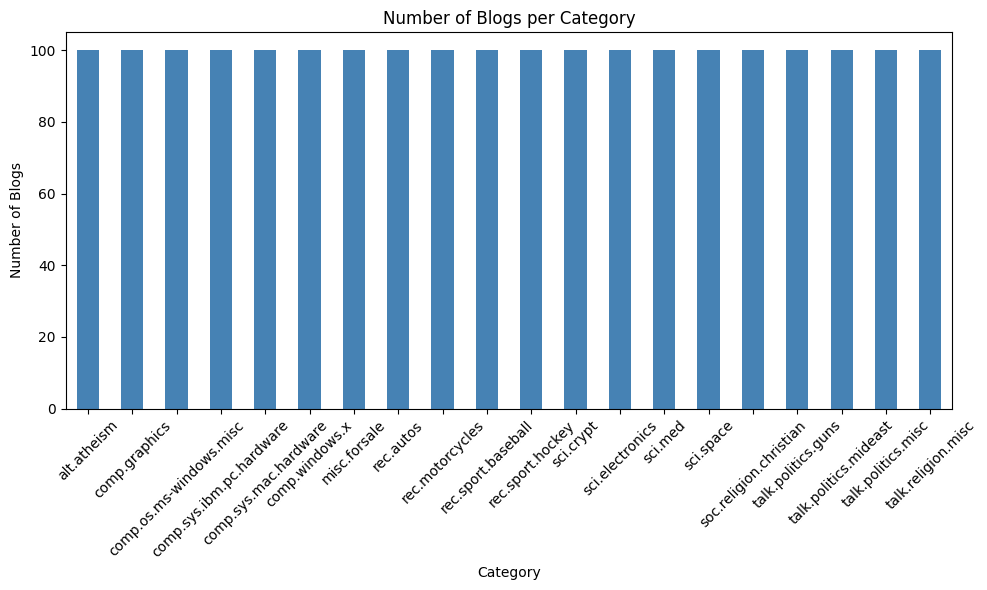

In [9]:
# Visualizing the no of blogs per Category
plt.figure(figsize=(10,6))
df['Labels'].value_counts().plot(kind = 'bar',color = 'steelblue')
plt.title('Number of Blogs per Category')
plt.xlabel('Category')
plt.ylabel('Number of Blogs')
plt.xticks(rotation 
           = 45)
plt.tight_layout()
plt.savefig('blogs_per_category.png')
plt.show()


In [10]:
# Save the cleaned dataset to a new CSV file
df.to_csv('cleaned_blogs.csv', index=False)